In [ ]:
import numpy as np
import matplotlib.pyplot as plt


import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # if notebook is in AMO-tools/notebooks
sys.path.insert(0, str(PROJECT_ROOT))

from data_analysis.data_analysis import load_data, load_param, fit_linear_background_iterative
from exp.science import laser_current_to_freq_MHz_2
from glob import glob

In [3]:
def plot(data_files, id, folder):
    data_file = data_files[id]
    data = load_data(data_file)
    i_mA =  data["current_mA"][20:100]
    det3491 = laser_current_to_freq_MHz_2(i_mA, 72.65)
    err = data["ch3_V"][20:100]
    value = data["ch1_V"][20:100]

    fig, ax1 = plt.subplots()

    # First y-axis
    ax1.plot(det3491, value)
    ax1.set_xlabel(r'$\Delta_{3491}$ (MHz)')
    ax1.set_ylabel('Signal')

    # Second y-axis sharing same x-axis
    ax2 = ax1.twinx()
    ax2.plot(det3491, err, '--', label='cos(x)', color="red")
    ax2.set_ylabel('Error Signal')
    ax2.hlines(0, -750, 1000, color="black")

    os.makedirs(folder, exist_ok=True)
    plt.savefig(folder+ f"/{id+1}.png")
    plt.show()

['../data/data-experiment/05182026/05182026-170442/data_01.csv'
 '../data/data-experiment/05182026/05182026-170442/data_02.csv'
 '../data/data-experiment/05182026/05182026-170442/data_03.csv'
 '../data/data-experiment/05182026/05182026-170442/data_04.csv'
 '../data/data-experiment/05182026/05182026-170442/data_05.csv'
 '../data/data-experiment/05182026/05182026-170442/data_06.csv'
 '../data/data-experiment/05182026/05182026-170442/data_07.csv'
 '../data/data-experiment/05182026/05182026-170442/data_08.csv']


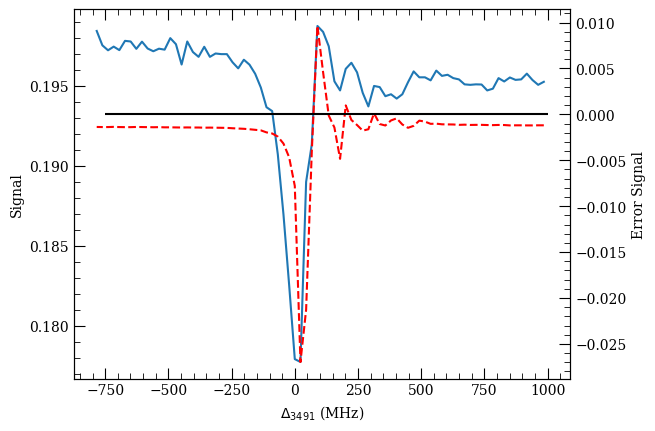

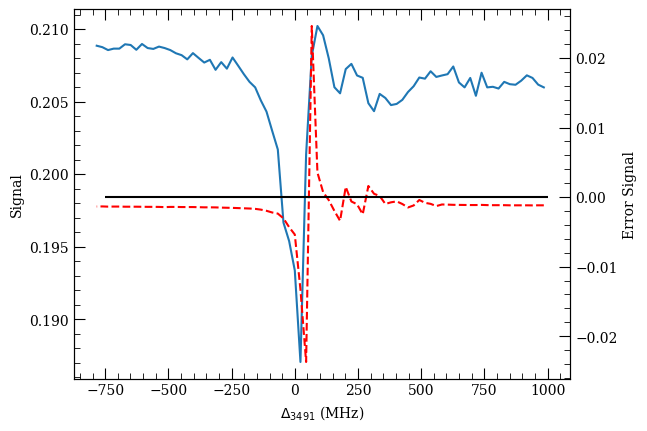

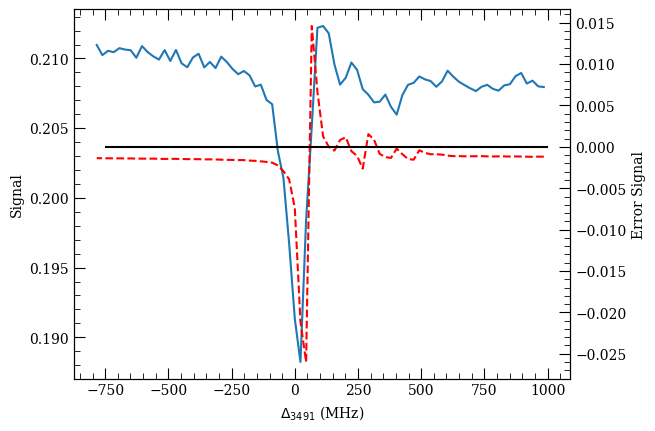

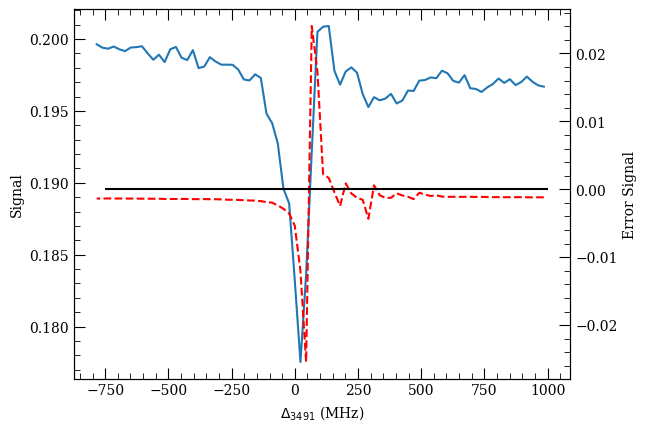

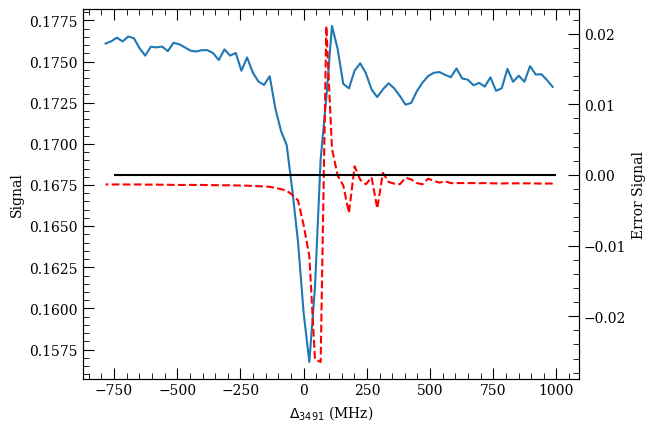

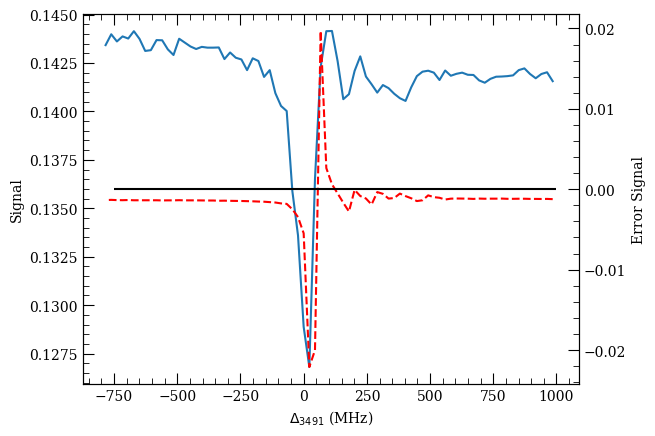

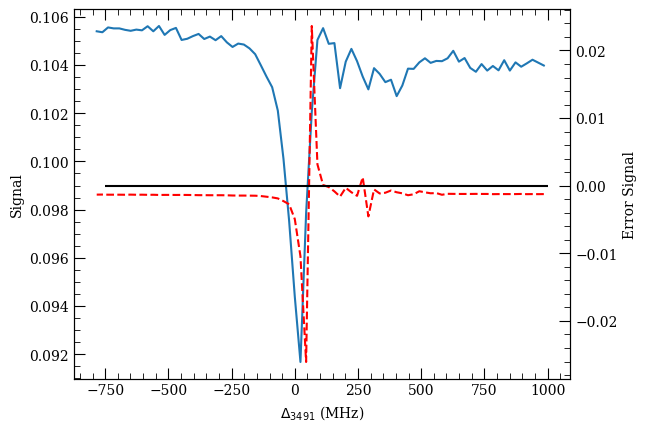

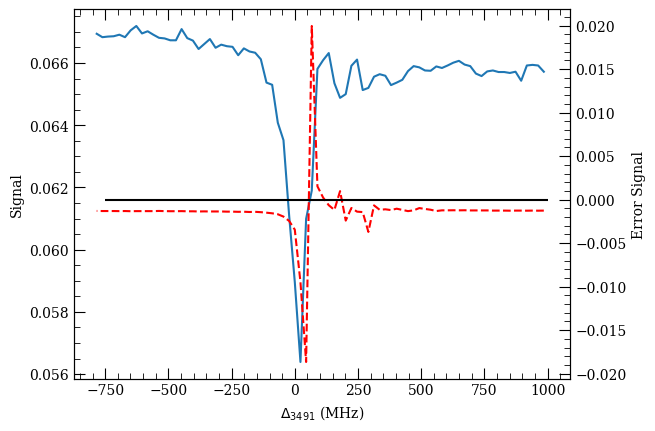

In [6]:
data_folder = "../data/data-experiment/05182026/05182026-170442/"
data_files = np.sort(glob(data_folder+"*.csv"))
print(data_files)
for idx in range(len(data_files)):
    plot(data_files, idx, folder = "fig/P852=6.68mW")

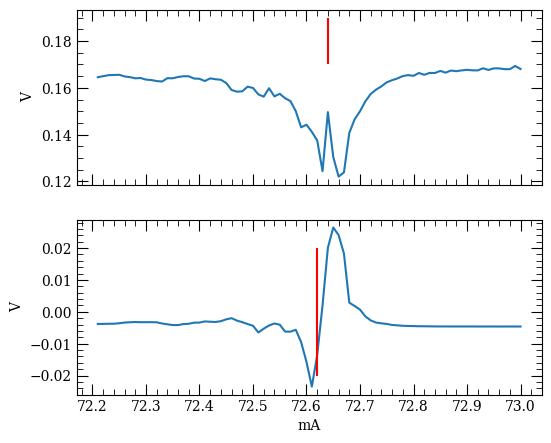

In [30]:
import matplotlib.pyplot as plt
import numpy as np


fig, (ax1, ax2) = plt.subplots(
    2, 1,          # 2 rows, 1 column
    sharex=True,   # same x-axis
    figsize=(6, 5)
)

# Top plot
ax1.plot(i_mA, value)
ax1.set_ylabel("V")
ax1.vlines(72.64, 0.17,0.19, color="red")

# Bottom plot
ax2.plot(i_mA, err)
ax2.set_ylabel("V")
ax2.set_xlabel("mA")
ax2.vlines(72.62, -0.02,0.02, color="red")

plt.show()

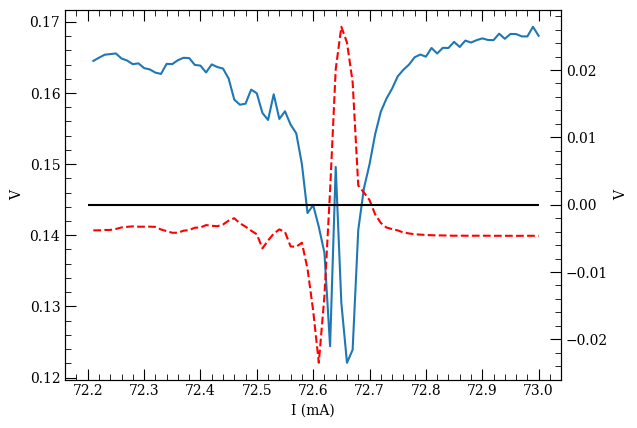

In [ ]:
fig, ax1 = plt.subplots()

# First y-axis
ax1.plot(i_mA, value)
ax1.set_xlabel('I (mA)')
ax1.set_ylabel('V')

# Second y-axis sharing same x-axis
ax2 = ax1.twinx()
ax2.plot(i_mA, err, '--', label='cos(x)', color="red")
ax2.set_ylabel('V')
ax2.hlines(0, 72.2, 73, color="black")

plt.show()

In [36]:
print(len(i_mA))

200


In [ ]:
data_folder = "../data/data-experiment/05162026/05162026-155923/"
data_file = glob(data_folder+"*.csv")[0]



def plot(data_file):
    data = load_data(data_file)
    i_mA =  data["current_mA"][20:100]
    err = data["ch3_V"][20:100]
    value = data["ch1_V"][20:100]

    fig, ax1 = plt.subplots()

    # First y-axis
    ax1.plot(i_mA, value)
    ax1.set_xlabel('I (mA)')
    ax1.set_ylabel('V')

    # Second y-axis sharing same x-axis
    ax2 = ax1.twinx()
    ax2.plot(i_mA, err, '--', label='cos(x)', color="red")
    ax2.set_ylabel('V')
    ax2.hlines(0, 72.2, 73, color="black")

    plt.show()